<a href="https://colab.research.google.com/github/senchiao/HRRR_plots/blob/main/2D_linear_flow_over_Mtn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

"""Simple 2-D linear flow over an idealized mountain.

This teaching script calculates the steady response of dry, stably stratified
air flowing from left to right over a smooth ridge. It uses linear Boussinesq
mountain-wave theory.

The model solves

    d2w/dx2 + d2w/dz2 + (N/U)^2 w = 0

with the lower boundary condition

    w(x, 0) = U dh/dx.

Here U is the background wind, N is the Brunt-Vaisala frequency, h is terrain
height, and w is vertical velocity. The solution is calculated in horizontal
Fourier space.

Important limitation
--------------------
This is a steady, dry, linear teaching model. It is not a weather forecast and
does not include clouds, precipitation, surface friction, rotation, wind
shear, nonlinear blocking, wave breaking, or time evolution.

How to run
----------
1. Install NumPy and Matplotlib if necessary:
       python -m pip install numpy matplotlib

2. Run this file:
       python idealized_mountain_wave.py

3. To make a new experiment, change one value in STUDENT SETTINGS below and
   run the file again.

What to expect
--------------
The script creates "idealized_mountain_wave.png". Gold shading represents
rising air, teal shading represents sinking air, and dark contours represent
streamlines. For left-to-right flow, the default run shows ascent on the
windward (left) slope and a mountain-wave pattern aloft.
"""


In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

In [2]:
# =============================================================================
# STUDENT SETTINGS: change one quantity at a time, then run the script again.
# =============================================================================

WIND_SPEED = 15.0          # U: background wind from left to right (m s^-1)
STABILITY = 0.010          # N: Brunt-Vaisala frequency (s^-1)
MOUNTAIN_HEIGHT = 500.0    # h0: maximum terrain height (m)
MOUNTAIN_WIDTH_KM = 20.0   # a: Gaussian e-folding half-width (km)

DOMAIN_HALF_WIDTH_KM = 150.0  # domain extends from -value to +value (km)
MODEL_TOP_KM = 15.0           # top of the plotted atmosphere (km)
NX = 1024                     # horizontal grid points (even and >= 128)
NZ = 181                      # vertical grid points (>= 40)

OUTPUT_FILE = "idealized_mountain_wave_500m.png"
SHOW_FIGURE = True  # Use False on a computer without a graphical display.


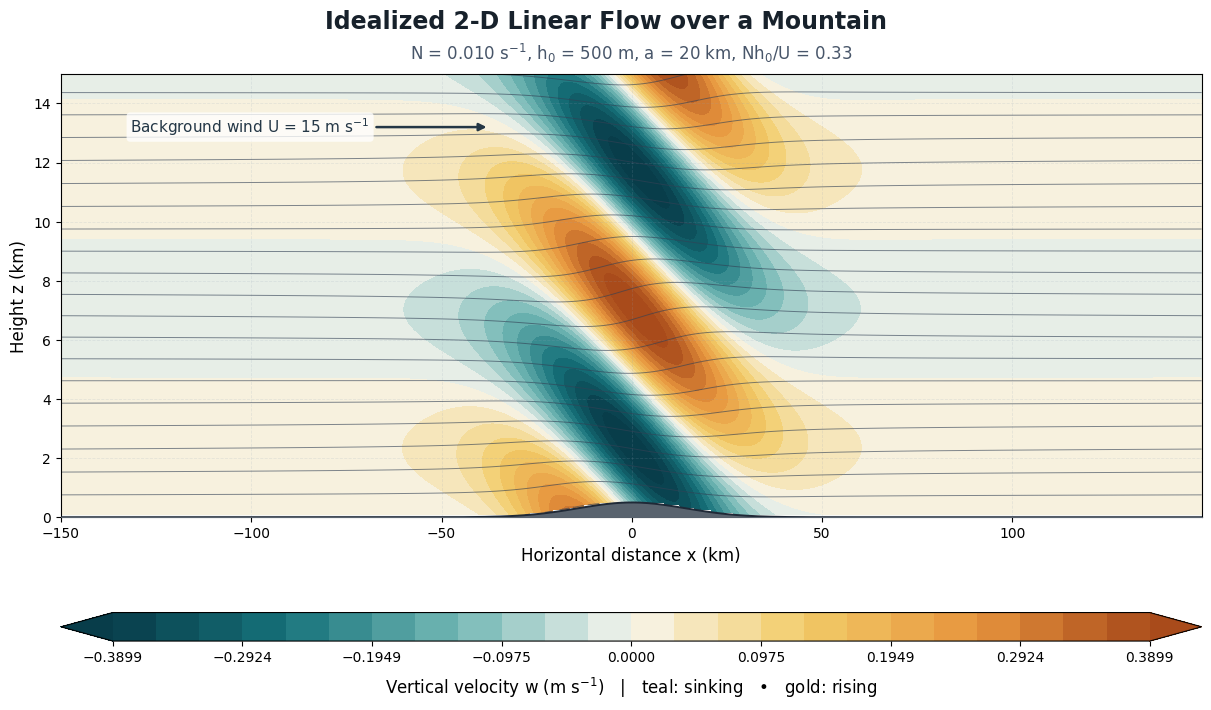


Idealized 2-D linear mountain-wave experiment
------------------------------------------------
Background wind U:             15.00 m s^-1
Brunt-Vaisala frequency N:    0.0100 s^-1
Mountain height h0:            500.0 m
Mountain width a:               20.0 km
Nondimensional height Nh0/U:   0.333
Approx. vertical wavelength:    9.42 km
Vertical velocity range:      -0.420 to 0.420 m s^-1
Boundary error (near zero):  1.11e-16 m s^-1
Figure saved to:             /content/idealized_mountain_wave_500m.png

Interpretation:
  Gold = rising air; teal = sinking air.
  Dark contours = streamlines.
  Change one setting at a time and compare the response.



In [3]:

def gaussian_mountain(x, height, width):
    """Create a smooth Gaussian mountain centered at x = 0.

    At x = +/- width, the terrain has fallen to height/e, or approximately
    37% of its peak value.
    """

    return height * np.exp(-((x / width) ** 2))


def check_inputs(U, N, h0, a, x_max, z_top, nx, nz):
    """Check inputs and warn when the linear approximation may be too weak.

    The nondimensional mountain height N*h0/U is an inverse Froude number.
    Linear theory is most appropriate when this number is much less than 1.
    """

    if U <= 0.0:
        raise ValueError("WIND_SPEED must be positive (flow is left to right).")
    if N <= 0.0:
        raise ValueError("STABILITY must be positive.")
    if h0 <= 0.0:
        raise ValueError("MOUNTAIN_HEIGHT must be positive.")
    if a <= 0.0:
        raise ValueError("MOUNTAIN_WIDTH_KM must be positive.")
    if x_max <= a:
        raise ValueError("DOMAIN_HALF_WIDTH_KM must exceed MOUNTAIN_WIDTH_KM.")
    if z_top <= h0:
        raise ValueError("MODEL_TOP_KM must be higher than the mountain.")
    if nx < 128 or nx % 2 != 0:
        raise ValueError("NX must be an even integer of at least 128.")
    if nz < 40:
        raise ValueError("NZ must be at least 40.")

    inverse_froude = N * h0 / U
    if inverse_froude > 0.5:
        warnings.warn(
            "N*h0/U is greater than 0.5. Nonlinear blocking or wave breaking "
            "may matter, but this linear model cannot represent them.",
            stacklevel=2,
        )

    # The FFT assumes a periodic domain. A wide domain makes the mountain
    # almost zero at both edges and minimizes artificial periodic effects.
    if x_max < 5.0 * a:
        warnings.warn(
            "The domain may be too narrow. Make DOMAIN_HALF_WIDTH_KM at least "
            "five times MOUNTAIN_WIDTH_KM.",
            stacklevel=2,
        )


def solve_linear_mountain_wave(U, N, h0, a, x_max, z_top, nx, nz):
    """Calculate vertical velocity and streamlines for the linear flow.

    For every horizontal Fourier wavenumber k, the vertical wavenumber m is

        m^2 = (N/U)^2 - k^2.

    Long horizontal waves have real m and propagate upward. Short horizontal
    disturbances have imaginary m and decay with height. The sign of real m
    is chosen to make wave energy propagate upward.

    Returns
    -------
    x, z : one-dimensional arrays (m)
    terrain : terrain height h(x) (m)
    w : vertical velocity on the x-z grid (m s^-1)
    streamline_height : a quantity whose contours are streamlines (m)
    boundary_error : numerical error in w(x,0) = U*dh/dx (m s^-1)
    """

    check_inputs(U, N, h0, a, x_max, z_top, nx, nz)

    # endpoint=False avoids duplicating a point on the periodic FFT grid.
    x = np.linspace(-x_max, x_max, nx, endpoint=False)
    z = np.linspace(0.0, z_top, nz)
    dx = x[1] - x[0]

    terrain = gaussian_mountain(x, h0, a)

    # Transform the terrain from physical space x to wavenumber space k.
    k = 2.0 * np.pi * np.fft.fftfreq(nx, d=dx)
    terrain_hat = np.fft.fft(terrain)

    # For constant wind and stability, the Scorer parameter is N/U.
    scorer = N / U

    # Choose a vertical wavenumber for each horizontal wavenumber.
    m = np.zeros_like(k, dtype=complex)
    propagating = (np.abs(k) <= scorer) & (k != 0.0)
    evanescent = np.abs(k) > scorer

    # sign(m) = sign(k) enforces upward energy propagation when U > 0.
    m[propagating] = (
        np.sign(k[propagating])
        * np.sqrt(scorer**2 - k[propagating] ** 2)
    )

    # A positive imaginary m makes exp(i*m*z) decay with height.
    m[evanescent] = 1j * np.sqrt(k[evanescent] ** 2 - scorer**2)

    # eta is the vertical displacement of a streamline. At z=0, eta=h(x).
    vertical_structure = np.exp(1j * z[:, None] * m[None, :])
    eta_hat = terrain_hat[None, :] * vertical_structure

    # The steady kinematic relation is w = U*d(eta)/dx.
    w_hat = 1j * k[None, :] * U * eta_hat
    eta = np.fft.ifft(eta_hat, axis=1).real
    w = np.fft.ifft(w_hat, axis=1).real

    # Contours of z-eta are streamlines of this linear solution.
    streamline_height = z[:, None] - eta

    # Verify the imposed lower boundary condition numerically.
    terrain_slope = np.fft.ifft(1j * k * terrain_hat).real
    expected_surface_w = U * terrain_slope
    boundary_error = np.max(np.abs(w[0, :] - expected_surface_w))

    return x, z, terrain, w, streamline_height, boundary_error


def plot_solution(
    x,
    z,
    terrain,
    w,
    streamline_height,
    output_file,
    U,
    N,
    h0,
    a_km,
    show_figure,
):
    """Make and save a distance-height plot of the mountain-wave solution."""

    # These settings use fonts bundled with Matplotlib, so the appearance is
    # consistent across Windows, macOS, and Linux without installing a font.
    plt.rcParams.update(
        {
            "font.family": "DejaVu Sans",
            "font.size": 11,
            "axes.titlesize": 12,
            "axes.titleweight": "medium",
            "axes.labelsize": 12,
            "axes.labelweight": "medium",
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
            "mathtext.fontset": "dejavusans",
            "figure.facecolor": "white",
            "axes.facecolor": "#F7F8F6",
        }
    )

    # Convert meters to kilometers only for plotting.
    x_km = x / 1000.0
    z_km = z / 1000.0
    terrain_km = terrain / 1000.0
    x_grid_km, z_grid_km = np.meshgrid(x_km, z_km)

    # Hide model values that are geometrically below the mountain.
    below_mountain = z_grid_km < terrain_km[None, :]
    w_visible = np.ma.masked_where(below_mountain, w)
    streamlines_visible = np.ma.masked_where(
        below_mountain,
        streamline_height / 1000.0,
    )

    # Use equal color limits for ascent and descent. The 99th percentile keeps
    # isolated values from controlling the entire color scale.
    color_limit = np.percentile(np.abs(w_visible.compressed()), 99.0)
    color_limit = max(float(color_limit), 0.01)
    color_levels = np.linspace(-color_limit, color_limit, 25)

    # A custom teal-to-gold palette clearly separates sinking and rising air.
    # The light neutral center corresponds to zero vertical velocity.
    teal_gold = LinearSegmentedColormap.from_list(
        "teal_gold",
        [
            "#083D4A",  # strong sinking
            "#16727A",
            "#73B8B5",
            "#F8F6EF",  # approximately zero
            "#F2CC68",
            "#E7953D",
            "#A94B1B",  # strong rising
        ],
    )

    fig, ax = plt.subplots(figsize=(12.0, 7.0), constrained_layout=True)

    shading = ax.contourf(
        x_grid_km,
        z_grid_km,
        w_visible,
        levels=color_levels,
        cmap=teal_gold,
        extend="both",
    )

    # Contours of the streamfunction show the path followed by the linear flow.
    streamline_levels = np.arange(0.0, z_km[-1] + 0.75, 0.75)
    ax.contour(
        x_grid_km,
        z_grid_km,
        streamlines_visible,
        levels=streamline_levels,
        colors="#334155",
        linewidths=0.70,
        alpha=0.62,
    )

    # Draw the mountain above the model fields.
    ax.fill_between(x_km, 0.0, terrain_km, color="#59636E", zorder=5)
    ax.plot(x_km, terrain_km, color="#1F2937", linewidth=1.4, zorder=6)

    # Make the imposed wind direction clear.
    # Place the arrow between streamline levels so it remains easy to see.
    arrow_height = 0.88 * z_km[-1]
    ax.annotate(
        f"Background wind U = {U:g} m s$^{{-1}}$",
        xy=(-0.25 * x_km[-1], arrow_height),
        xytext=(-0.88 * x_km[-1], arrow_height),
        arrowprops={
            "arrowstyle": "-|>",
            "linewidth": 1.8,
            "color": "#243746",
        },
        ha="left",
        va="center",
        color="#243746",
        fontweight="medium",
        bbox={
            "boxstyle": "round,pad=0.25",
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.78,
        },
        zorder=10,
    )

    inverse_froude = N * h0 / U
    fig.suptitle(
        "Idealized 2-D Linear Flow over a Mountain",
        fontsize=17,
        fontweight="semibold",
        color="#17212B",
    )
    ax.set_title(
        f"N = {N:.3f} s$^{{-1}}$, "
        f"h$_0$ = {h0:g} m, "
        f"a = {a_km:g} km, "
        f"Nh$_0$/U = {inverse_froude:.2f}",
        color="#475569",
        pad=10,
    )
    ax.set_xlabel("Horizontal distance x (km)")
    ax.set_ylabel("Height z (km)")
    ax.set_xlim(x_km[0], x_km[-1])
    ax.set_ylim(0.0, z_km[-1])
    ax.grid(color="#94A3B8", linestyle="--", linewidth=0.6, alpha=0.18)

    colorbar = fig.colorbar(
        shading,
        ax=ax,
        orientation="horizontal",
        pad=0.10,
        fraction=0.075,
        aspect=40,
    )
    colorbar.set_label(
        "Vertical velocity w (m s$^{-1}$)   |   teal: sinking   •   gold: rising",
        labelpad=8,
    )
    colorbar.ax.tick_params(labelsize=10)

    # This is the only file written by the program.
    fig.savefig(output_file, dpi=180)
    if show_figure:
        plt.show()
    plt.close(fig)


def main():
    """Run one experiment using the STUDENT SETTINGS near the top of the file."""

    # Convert the settings expressed in kilometers to SI units (meters).
    a = MOUNTAIN_WIDTH_KM * 1000.0
    x_max = DOMAIN_HALF_WIDTH_KM * 1000.0
    z_top = MODEL_TOP_KM * 1000.0

    x, z, terrain, w, streamlines, boundary_error = (
        solve_linear_mountain_wave(
            U=WIND_SPEED,
            N=STABILITY,
            h0=MOUNTAIN_HEIGHT,
            a=a,
            x_max=x_max,
            z_top=z_top,
            nx=NX,
            nz=NZ,
        )
    )

    output_path = Path(OUTPUT_FILE)
    plot_solution(
        x=x,
        z=z,
        terrain=terrain,
        w=w,
        streamline_height=streamlines,
        output_file=output_path,
        U=WIND_SPEED,
        N=STABILITY,
        h0=MOUNTAIN_HEIGHT,
        a_km=MOUNTAIN_WIDTH_KM,
        show_figure=SHOW_FIGURE,
    )

    inverse_froude = STABILITY * MOUNTAIN_HEIGHT / WIND_SPEED
    vertical_wavelength = 2.0 * np.pi * WIND_SPEED / STABILITY

    print("\nIdealized 2-D linear mountain-wave experiment")
    print("------------------------------------------------")
    print(f"Background wind U:           {WIND_SPEED:7.2f} m s^-1")
    print(f"Brunt-Vaisala frequency N:   {STABILITY:7.4f} s^-1")
    print(f"Mountain height h0:          {MOUNTAIN_HEIGHT:7.1f} m")
    print(f"Mountain width a:            {MOUNTAIN_WIDTH_KM:7.1f} km")
    print(f"Nondimensional height Nh0/U: {inverse_froude:7.3f}")
    print(f"Approx. vertical wavelength: {vertical_wavelength / 1000.0:7.2f} km")
    print(f"Vertical velocity range:     {w.min():7.3f} to {w.max():.3f} m s^-1")
    print(f"Boundary error (near zero):  {boundary_error:7.2e} m s^-1")
    print(f"Figure saved to:             {output_path.resolve()}")
    print("\nInterpretation:")
    print("  Gold = rising air; teal = sinking air.")
    print("  Dark contours = streamlines.")
    print("  Change one setting at a time and compare the response.\n")


if __name__ == "__main__":
    main()